INTRODUCTION

This project analyzes data from the titanic disaster 

DATA DESCRIPTION:
- the data contains passenger id,survived (0-dead,1-survived), passenger class(pclass-1-firstclass,2-secondclass,3-thirdclass), name, sex, age, number of siblings/spouse onboard(sibsp), the number of parents and children onboard(parch),ticket,fare,cabin and embarked(port of embarkation-S-southampton ,C-cebork ,Q-queenstown).

-the  data contains 891 rows and 12 columns

DATA CLEANING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\luqsu\OneDrive\Desktop\New folder\WAStatusSaver\train.csv")
pd.set_option('display.max.rows',892)
pd.set_option('display.max.columns',13)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.0708,NaN,C


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

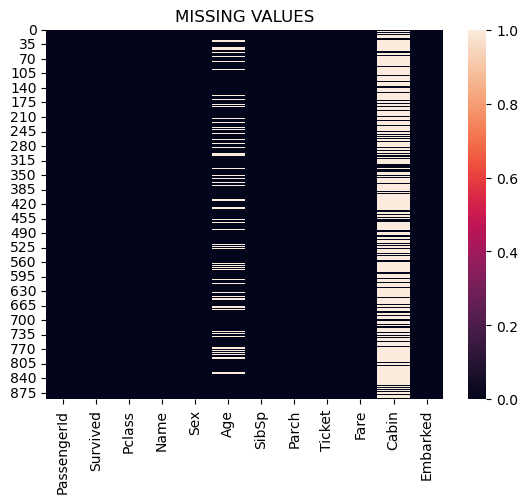

In [8]:
sns.heatmap(df.isna())
plt.title('MISSING VALUES')
plt.show()

In [9]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [10]:
col_to_fill={'Fare':0,'Embarked':'S'}
df.fillna(col_to_fill,inplace=True)


In [11]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
#df.dropna(subset='Age',inplace=True)- alternative approach to handling null values
df.drop('Cabin',axis=1,inplace=True)

C:\Users\luqsu\AppData\Local\Temp\ipykernel_4972\386840032.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [12]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [13]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

FEATURE ENGINEERING/EDA

NUMBER OF MALE PASSENGERS ONBOARD THE TITANIC

In [14]:
m=sum(df['Sex']=='male')
print(f'The number  of male passengers aboard the titanic is: {m}.')

The number  of male passengers aboard the titanic is: 577.


NUMBER OF FEMALE PASSENGERS ONBOARD THE TITANIC

In [15]:
f=sum(df['Sex']=='female')
print(f'The number  of female passengers aboard the titanic is: {f}.')

The number  of female passengers aboard the titanic is: 314.


CATEGORICAL DATA ENCODING

In [16]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [17]:
W=df['Sex'].map({'male':1,'female':0})

In [18]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [19]:

df.insert(5,'Gender',W)

In [20]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,0,26.0,0,0,STON/O2. 3101282,7.9250,S


In [21]:
df['Embarked'].nunique()

3

In [22]:
df1=pd.get_dummies(df,columns=['Embarked'])

In [23]:
df1

,PassengerId,Survived,Pclass,Name,Sex,Gender,...,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,1,...,0,A/5 21171,7.2500,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0,...,0,PC 17599,71.2833,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,0,...,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0,...,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,1,...,0,373450,8.0500,False,False,True
5,6,0,3,"Moran, Mr. James",male,1,...,0,330877,8.4583,False,True,False
6,7,0,1,"McCarthy, Mr. Timothy J",male,1,...,0,17463,51.8625,False,False,True
7,8,0,3,"Palsson, Master. Gosta Leonard",male,1,...,1,349909,21.0750,False,False,True
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,0,...,2,347742,11.1333,False,False,True
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,0,...,0,237736,30.0708,True,False,False


UNIVARIATE EDA

NUMBER OF SURVIVORS

In [42]:
x=df['Survived'].value_counts()
x

Survived
0    549
1    342
Name: count, dtype: int64

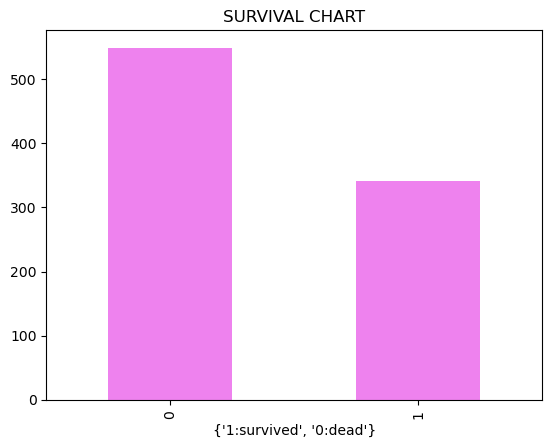

In [43]:
x.plot(kind='bar',color='violet')
plt.xlabel({'0:dead','1:survived'})
plt.title('SURVIVAL CHART')
plt.show()

NUMBER OF PASSENGERS IN EACH CLASS

In [44]:
y=df['Pclass'].value_counts()
y

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

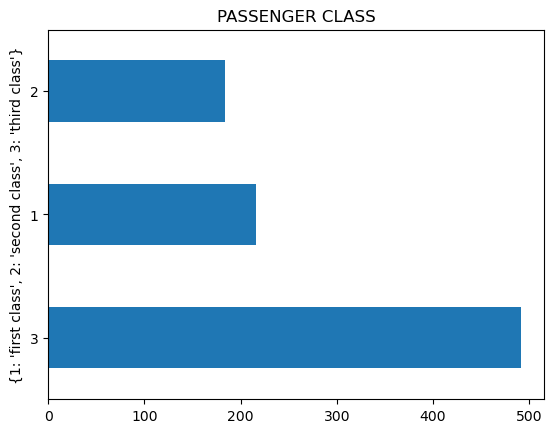

In [45]:
y.plot(kind='barh')
plt.ylabel({1:'first class',2:'second class',3:'third class'})
plt.title('PASSENGER CLASS')
plt.show()

NUMBER OF MALE AND FEMALE PASSENGERS

In [46]:
c=df['Sex'].value_counts()
c

Sex
male      577
female    314
Name: count, dtype: int64

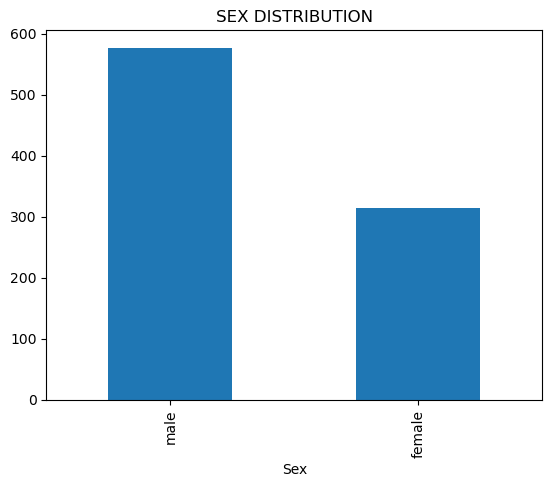

In [47]:
c.plot(kind='bar')
plt.title('SEX DISTRIBUTION')
plt.show()

AGE DISTRIBUTION

(array([ 54.,  46., 177., 346., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

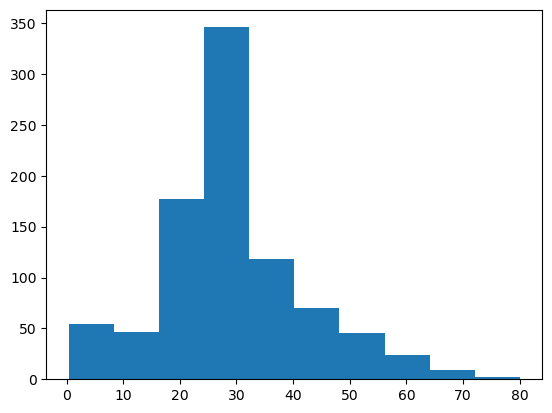

In [48]:
plt.hist(df['Age'])

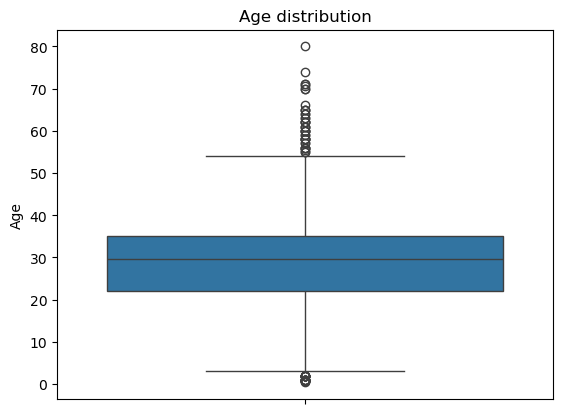

In [49]:
sns.boxplot(df['Age'],orient='v')
plt.title('Age distribution')
plt.show()

In [51]:
#use histogram and boxplots for uncontinious variables-they're used to find the frequency of numerical values

BIVARIATE EDA-RELATIONSHIPS

In [54]:
#Target variable i.e survived is the dependent variable(y) while the other variables are the independent variables(x).
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Gender', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

SURVIVAL RATE BY SEX

<Axes: xlabel='Sex', ylabel='Survived'>

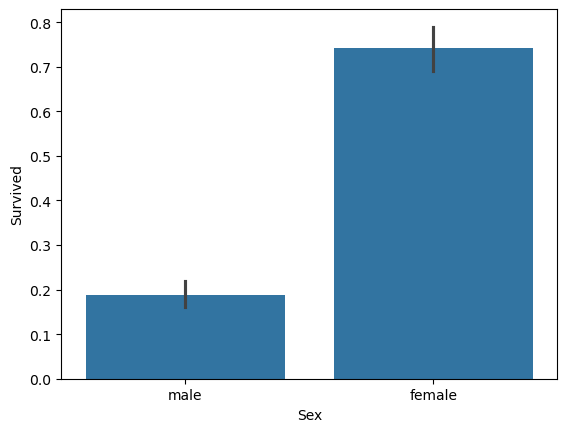

In [55]:
#Barplots-for comparison of categorical data
sns.barplot(data=df,x='Sex',y='Survived')

SURVIVAL RATE BY PASSENGER CLASS

<Axes: xlabel='Pclass', ylabel='Survived'>

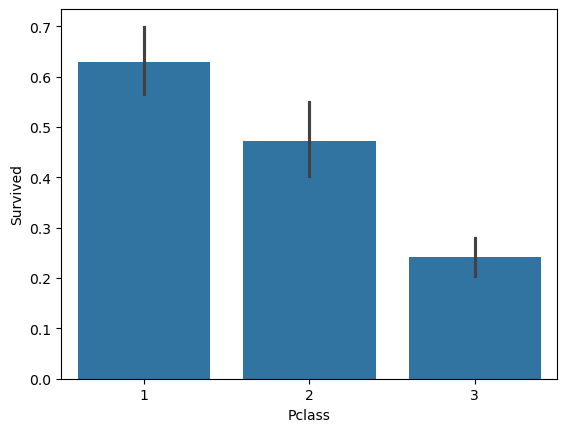

In [56]:
sns.barplot(data=df,x='Pclass',y='Survived')

FEATURE ENGINEERING

In [57]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Gender', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [58]:
df['Family_size']=df['Parch']+df['SibSp']

In [59]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,1,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0,38.0,1,0,PC 17599,71.2833,C,1


In [60]:
df['Fare_per_passenger']=df['Fare']/(df['Family_size']+1)

In [61]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Gender,...,Parch,Ticket,Fare,Embarked,Family_size,Fare_per_passenger
0,1,0,3,"Braund, Mr. Owen Harris",male,1,...,0,A/5 21171,7.2500,S,1,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0,...,0,PC 17599,71.2833,C,1,35.64165


In [62]:
df.to_csv("Cleaned Titanic data.csv",index=False)